In [1]:
import torch
import numpy as np
import splinepy as sp
import matplotlib.pyplot as plt

import deep_sdf.workspace as ws
import deep_sdf.utils
from sdf_sampler.plotting import scatter_contour_at_origin
import os
os.chdir("/usr2/mkofler/DeepSDF_microstructures")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

experiment_directory = "./experiments/round_cross_big_network"
checkpoint = "1000"

params = {'text.usetex': True}
plt.rcParams.update(params)

latent = ws.load_latent_vectors(experiment_directory, checkpoint).to("cpu").numpy()
decoder = ws.load_trained_model(experiment_directory, checkpoint).to(device)
decoder.eval()
graded = True

In [2]:
n_points = 5
# control_points = np.linspace(0.25, 1, n_points).reshape(-1,1)
control_points = [[0.5], [0.25], 
                  [0.8], [0.8]]

In [3]:
# knot_vec_const = np.linspace(-1,1,n_points+1)
# discrete_interpolation = sp.BSpline(
#     degrees=[0, 0, 0],
#     knot_vectors=[knot_vec_const,
#                   [-1,1],
#                   [-1,1]],
#     control_points=control_points,
# )
lin = np.linspace(-1,1,n_points)
# knot_vec_interpolate = np.concatenate(([-1,], lin, [1,]))
# print(knot_vec_interpolate)
continuos_interpolation = sp.BSpline(
    degrees=[1, 1, 0],
    knot_vectors=[[-1,-1, 1, 1],
                  [-1,-1, 1, 1],
                  [-1,1]],
    control_points=control_points,
)
print(control_points)
# x = np.linspace(-1, 1, 1000).reshape(-1,1)
# y = np.zeros_like(x)
# z = np.zeros_like(x)
# fig, ax = plt.subplots(2,1)
# ax[0].plot(x, discrete_interpolation.evaluate(np.hstack([x,y,z])))
# ax[1].plot(x, continuos_interpolation.evaluate(np.hstack([x,y,z])))

[[0.5], [0.25], [0.8], [0.8]]


In [4]:
def transform(x, t):
    p = 2/t
    return (2/p)*torch.abs((x-t%2) % (p*2) - p) -1 

def sdf_struct(queries, latent_vec_interpolation, tiling=[5, 1, 1]):
    queries = torch.tensor(queries, dtype=torch.float32).to(device)
    tx, ty, tz = tiling[0], tiling[1], tiling[2]
    samples = torch.zeros(queries.shape[0], 3)
    samples[:, 0] = transform(queries[:, 0], tx)
    samples[:, 1] = transform(queries[:, 1], ty)
    samples[:, 2] = transform(queries[:, 2], tz)
    lat_vec_red = torch.tensor(latent_vec_interpolation.evaluate(queries.cpu().numpy()), dtype=torch.float32)
    queries = torch.hstack([torch.tensor(lat_vec_red).to(torch.float32).to(device), samples])

    return deep_sdf.utils.decode_sdf(decoder, None, queries).squeeze(1).detach().cpu().numpy()

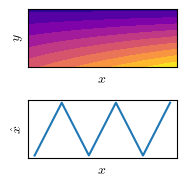

In [5]:
# Compute the z values for the grid
fig, axs = plt.subplots(2, 1, figsize=(5/2.54, 5/2.54))
n_eval = 1000
x = np.linspace(-1, 1, n_eval)
y = np.linspace(-1, 1, n_eval)
X, Y = np.meshgrid(x, y)
queries = np.hstack([X.reshape(-1,1), Y.reshape(-1,1), np.zeros_like(Y.reshape(-1,1))])
Z = continuos_interpolation.evaluate(queries)
# z_show = np.sqrt(Z[:,0]**2 + Z[:,1]**2).reshape(X.shape)
z_show = Z[:,0].reshape(X.shape)
# z_show = Z[:,1].reshape(X.shape)
# negative for color reversal
axs[0].contourf(X, Y, -Z[:,0].reshape(X.shape), 10, cmap="plasma")


r = Z[:,0].reshape(X.shape)
control_points_for_min_max = np.vstack([control_points, control_points])

r_min = control_points_for_min_max[:,0].min()
r_max = control_points_for_min_max[:,0].max()
# g_min = control_points_for_min_max[:,1].min()
# g_max = control_points_for_min_max[:,1].max()
r_norm = (r-r_min)/(r_max-r_min) 
# g_norm = (g-g_min)/(g_max-g_min)

axs[0].set_xticks([]) 
axs[0].set_yticks([]) 
axs[0].set_xlabel(r"$x$")
axs[0].set_ylabel(r"$y$")

axs[1].set_xticks([]) 
axs[1].set_yticks([]) 
axs[1].set_xlabel(r"$x$")
axs[1].set_ylabel(r"$\hat{x}$")

x = np.linspace(-1,1,1000)
y = transform(torch.tensor(x), 5)
axs[1].plot(x,y.cpu())
fig.tight_layout()
plt.savefig(f"evaluation_scripts/AICOMAS2024/plots/inputs_network.png", dpi=600, bbox_inches="tight")

/tmp/ipykernel_2418487/885622797.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  queries = torch.hstack([torch.tensor(lat_vec_red).to(torch.float32).to(device), samples])


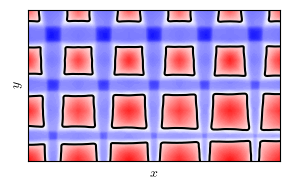

In [6]:
# continuos_interpolation.control_points = np.zeros_like(continuos_interpolation.control_points) + 0.8
# plt.savefig("evaluation_scripts/IGA2024/plots/struct_before_FFD.png", dpi=600, bbox_inches="tight")

fig, ax = plt.subplots(1, 1, figsize=(5/2.54*10/4, 5/2.54))
scatter_contour_at_origin(lambda queries: sdf_struct(queries, continuos_interpolation, tiling=[5,3,3]), flip_axes=True, res=1000, scale=3/5, custom_axis=ax)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
plt.savefig(f"evaluation_scripts/AICOMAS2024/plots/graded_structure.png", dpi=600, bbox_inches="tight")

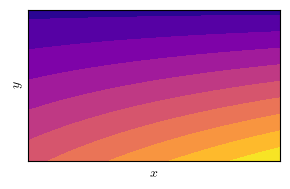

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(5/2.54*10/4, 5/2.54))
ax.contourf(X, Y, -Z[:,0].reshape(X.shape), 10, cmap="plasma")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")
ax.set_aspect(3/5)
ax.set_xticks([]) 
ax.set_yticks([]) 
plt.savefig(f"evaluation_scripts/AICOMAS2024/plots/graded_latent_space.png", dpi=600, bbox_inches="tight")